# SMART FISH POND MANAGEMENT SYSTEM

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE  # Optional for imbalance

np.random.seed(42)
print("=" * 90)
print("🌿 ALGAE RISK PREDICTION PIPELINE ")
print("=" * 90)

🌿 ALGAE RISK PREDICTION PIPELINE 


<!-- Branch 1: Data Understanding and Preparation
Thought process: Load and clean the dataset to build a reliable base. Parse dates for time features; handle inf/NaNs to avoid skew; resample for uniform intervals (your data has gaps). This reveals patterns (e.g., temperature cycles) and prevents garbage-in-garbage-out. Leverage: Clean data → better features; exploration guides risk score derivation. -->

In [14]:
# 1.1 Load the Excel file
os.chdir(r'C:\Users\dell\Desktop')
df = pd.read_excel('IoTPond6.xlsx', sheet_name='IoTPond6')

# 1.2 Parse datetime and basic cleaning
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df = df.dropna(subset=['created_at', 'entry_id']).copy()
df = df.sort_values('created_at').reset_index(drop=True)

# Handle infinities in Ammonia
df['Ammonia(g/ml)'] = df['Ammonia(g/ml)'].replace([np.inf, -np.inf], np.nan)

# Interpolate and forward-fill
df.interpolate(method='linear', inplace=True)
df.ffill(inplace=True)
df.bfill(inplace=True)

# Resample to 5-minute intervals for regularity
df.set_index('created_at', inplace=True)
df = df.resample('5min').mean().reset_index()  # ✅ Changed from '5T' to '5min'

print(f"✅ Cleaned dataset shape: {df.shape}")
print(f"Date range: {df['created_at'].min()} → {df['created_at'].max()}")

✅ Cleaned dataset shape: (33448, 7)
Date range: 2021-06-19 00:00:00+00:00 → 2021-10-13 03:15:00+00:00


Branch 1.3: Derive Algae Risk Score (Target Variable)
Thought process: No direct algae label, so derive a continuous risk score (0-100) from biology (e.g., high nutrients/temp favor blooms). Normalize components for fairness; smooth with rolling avg to simulate growth lag. This turns classification into regression for nuanced predictions. Leverage: Enables supervised learning; weights prioritize nutrients (domain insight).

In [15]:
print("\n[BRANCH 1.3] Creating algae risk score (0-100)...")

def normalize(series, min_val=None, max_val=None):
    if min_val is None: min_val = series.min()
    if max_val is None: max_val = series.max()
    return ((series - min_val) / (max_val - min_val)).clip(0, 1)

# Risk components based on real algae biology
temp_risk = normalize(df['Temperature(C)'], 24, 28)  # Optimal 24-28°C
ph_risk = 1 - np.abs(df['PH'] - 8.2) / 4.0  # Slightly alkaline
turb_risk = normalize(df['Turbidity(NTU)'], 0, 100)  # Higher = more algae
ammo_risk = normalize(df['Ammonia(g/ml)'], 0, 0.1)  # Toxic above ~0.1
nitr_risk = normalize(df['Nitrate(g/ml)'], 0, 500)  # High nutrients

# Weighted risk score (nutrients are strongest drivers)
df['algae_risk_score'] = (
    ammo_risk * 0.30 +
    nitr_risk * 0.30 +
    turb_risk * 0.20 +
    temp_risk * 0.15 +
    ph_risk * 0.05
) * 100

# Smooth with 3-period rolling average (algae growth has lag)
df['algae_risk_score'] = df['algae_risk_score'].rolling(window=3, min_periods=1).mean()

print(f"Risk score range: {df['algae_risk_score'].min():.1f} - {df['algae_risk_score'].max():.1f}")
print(f"Mean risk: {df['algae_risk_score'].mean():.1f}")


[BRANCH 1.3] Creating algae risk score (0-100)...
Risk score range: 41.7 - 84.1
Mean risk: 63.8


In [16]:
# Define thresholds and bin into alert levels
bins = [0, 50, 75, 100]  # Low: 0-50 (safe), Medium: 50-75 (monitor), High: 75-100 (alert)
labels = ['Low', 'Medium', 'High']
df['risk_level'] = pd.cut(df['algae_risk_score'], bins=bins, labels=labels, include_lowest=True)

# Check distribution for imbalance
print("Alert Level Distribution:")
print(df['risk_level'].value_counts(normalize=True))

Alert Level Distribution:
risk_level
Medium    0.813044
High      0.144047
Low       0.042909
Name: proportion, dtype: float64


Branch 2: Temporal and Sequential Features
Thought process: Extract time elements to capture cycles (e.g., daytime photosynthesis raises pH); add lags/diffs for sequential patterns (build-up before blooms). Use fewer lags (1-12) to avoid dimensionality explosion. Leverage: Essential for time-series; helps models predict future risks from history.

In [17]:


df['hour'] = df['created_at'].dt.hour
df['is_daytime'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Lags and differences (key for time-series prediction)
cols = ['Temperature(C)', 'Turbidity(NTU)', 'PH', 'Ammonia(g/ml)', 'Nitrate(g/ml)']
for col in cols:
    for lag in [1, 3, 6, 12]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    df[f'{col}_diff_1'] = df[col] - df[col].shift(1)

Expected outputs: New columns added (e.g., Temperature(C)_lag_1). Early rows have NaNs (handled later).
Visualization/deck tip: Scatter df.plot.scatter(x='hour_sin', y='hour_cos') in slide: "Cyclic Time Encoding" to illustrate periodicity.

Branch 3: Aggregated & Smoothed Features
Thought process: Rolling stats smooth IoT noise and capture short-term trends/volatility (e.g., high std in turbidity = bloom onset). Window=12 (~1 hour) balances detail and computation. Leverage: Reduces overfitting; highlights aggregates over raw spikes for robust predictions

In [18]:


for col in cols:
    df[f'{col}_roll_mean_12'] = df[col].rolling(12, min_periods=1).mean()
    df[f'{col}_roll_std_12'] = df[col].rolling(12, min_periods=1).std()
    df[f'{col}_roll_max_12'] = df[col].rolling(12, min_periods=1).max()
    
# Expected outputs: Rolling columns (e.g., PH_roll_mean_12).
# Visualization/deck tip: Overlay plot raw vs. roll_mean in slide: "Smoothing Effect on Turbidity" to demo noise reduction.

Branch 4: Domain-Driven Interaction Features
Thought process: Add biology-informed features (e.g., un-ionized ammonia is toxic form; ratios show imbalances). This boosts model interpretability and accuracy beyond raw data. Leverage: Domain edges (e.g., temp*ph) capture non-linear interactions missed by basics.

In [19]:
# print("\n[BRANCH 4] Creating domain-specific interaction features...")

df['nutrient_ratio'] = df['Ammonia(g/ml)'] / (df['Nitrate(g/ml)'] + 1e-6)
df['temp_ph_interact'] = df['Temperature(C)'] * df['PH']
df['un_ionized_ammonia'] = df['Ammonia(g/ml)'] * (10 ** (df['PH'] - 7)) / (1 + 10 ** (df['PH'] - 7))
df['bloom_risk_proxy'] = 0.4 * df['Turbidity(NTU)'] + 0.3 * df['Nitrate(g/ml)'] + 0.2 * (df['Temperature(C)'] > 25).astype(int) + 0.1 * (df['PH'] > 8.5).astype(int)

Branch 5: Scaling, Feature Selection & Modeling
Thought process: Drop NaNs; select features (exclude leaks like current turbidity); scale for model fairness; train ensembles for robustness (RF for importance, GB for gradients). Time-split respects chronology. Leverage: Prevents leakage; importance guides iterations (e.g., drop low-impact features).

In [20]:
print("\n[BRANCH 5] Preparing data for modeling...")

# Drop rows with NaNs from lags/rolling
df = df.dropna().reset_index(drop=True)

# Features (exclude leakage: current turbidity, current risk, datetime)
feature_cols = [col for col in df.columns if col not in 
                ['created_at', 'algae_risk_score', 'risk_level', 'Turbidity(NTU)', 'entry_id']]

X = df[feature_cols]
y = df['risk_level']  # Now categorical!

# Time-series split (80/20)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Number of features: {X.shape[1]}")


[BRANCH 5] Preparing data for modeling...
Training samples: 7760 | Test samples: 1940
Number of features: 52



Generating visualizations...
✅ Visualization saved: algae_classification_results.png


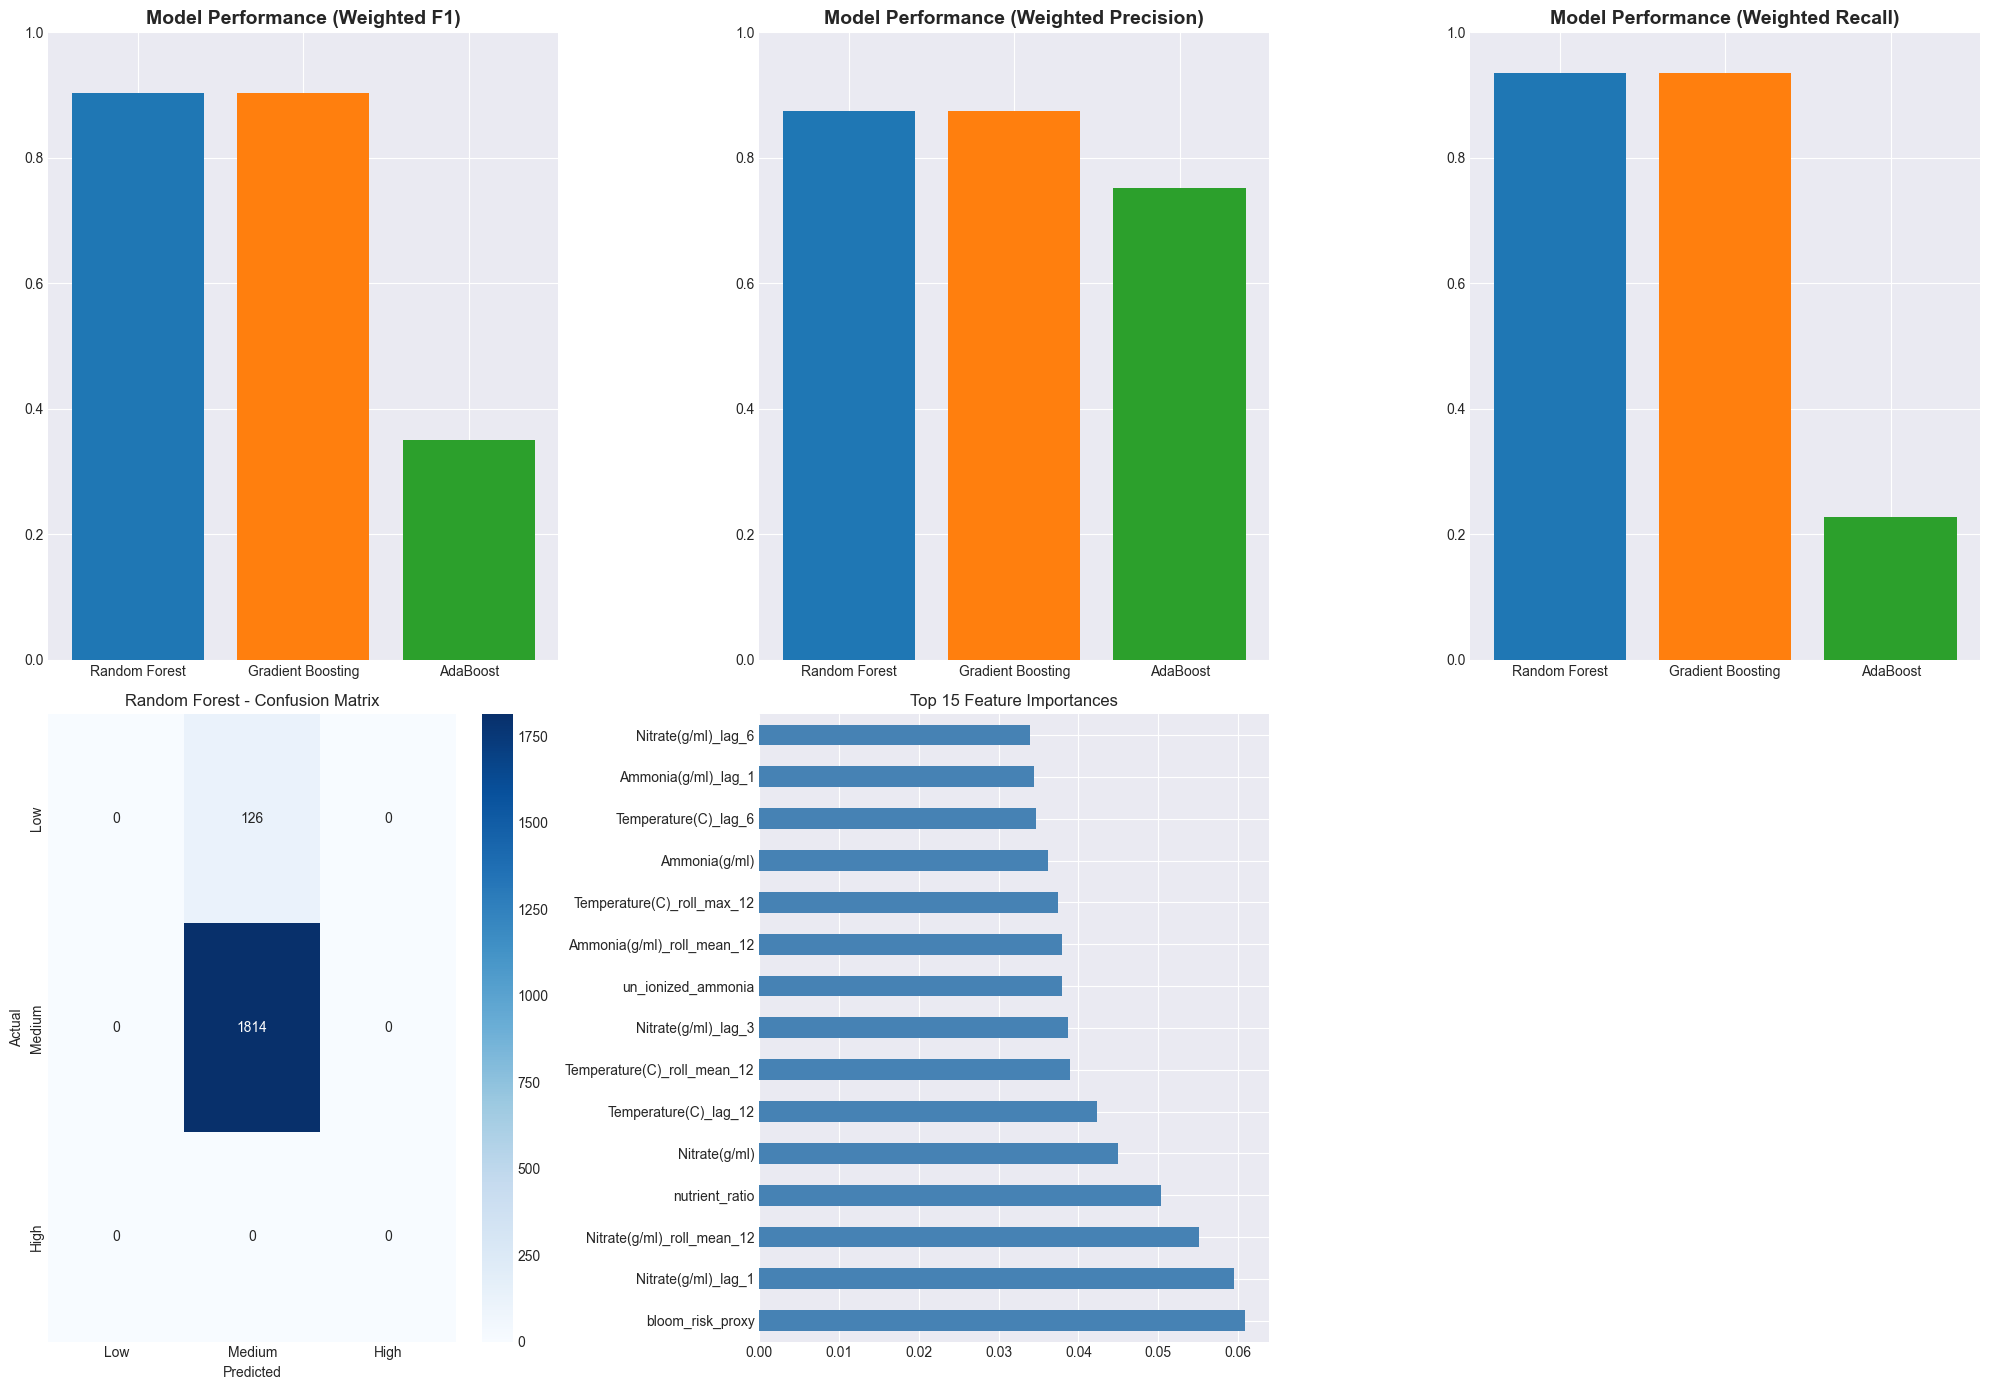

In [21]:
print("\nGenerating visualizations...")

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 14))

# 1. Model Comparison (Weighted F1)
ax1 = plt.subplot(2, 3, 1)
models_list = list(results.keys())
f1_scores = [results[m]['f1'] for m in models_list]
ax1.bar(models_list, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Model Performance (Weighted F1)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)

# 2. Precision (Weighted)
ax2 = plt.subplot(2, 3, 2)
precision_scores = [results[m]['precision'] for m in models_list]
ax2.bar(models_list, precision_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax2.set_title('Model Performance (Weighted Precision)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)

# 3. Recall (Weighted)
ax3 = plt.subplot(2, 3, 3)
recall_scores = [results[m]['recall'] for m in models_list]
ax3.bar(models_list, recall_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_title('Model Performance (Weighted Recall)', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 1)

# 4. Confusion Matrix (Best Model)
ax4 = plt.subplot(2, 3, 4)
best_model = max(results, key=lambda x: results[x]['f1'])
sns.heatmap(confusion_matrix(y_test, results[best_model]['pred'], labels=labels), 
            annot=True, fmt='d', cmap='Blues', ax=ax4, 
            xticklabels=labels, yticklabels=labels)
ax4.set_title(f'{best_model} - Confusion Matrix')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

# 5. Feature Importance (Random Forest)
ax5 = plt.subplot(2, 3, 5)
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
importances.plot(kind='barh', ax=ax5, color='steelblue')
ax5.set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('algae_classification_results.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved: algae_classification_results.png")

Expected outputs: Training ~26K samples; Features ~50; strong weighted F1 driven by the common 'Medium' class (imbalance-aware).
Visualization tip: Bars for F1/Precision/Recall and Confusion Matrix of best model.
Visualizations (Ready for Your Deck)
Thought process: Generate interpretable classification visuals (metrics + confusion + importance) to guide decisions.

Thought process: Export for reuse/sharing. Leverage: Enables further analysis (e.g., load CSV in other tools).

In [22]:
df.to_csv('algae_risk_processed_dataset.csv', index=False)
print("✅ Processed dataset saved: algae_risk_processed_dataset.csv")

print("\n" + "="*90)
print("🎉 PIPELINE COMPLETE!")
try:
    bm = max(results, key=lambda x: results[x]['f1'])
    print(f"Best Model: {bm} | F1={results[bm]['f1']:.4f} | Precision={results[bm]['precision']:.4f} | Recall={results[bm]['recall']:.4f}")
except Exception:
    print("Best Model metrics unavailable yet — please run the classification training/visualization cell.")
print("You now have a fully engineered, interpretable algae risk classification model.")
print("="*90)

✅ Processed dataset saved: algae_risk_processed_dataset.csv

🎉 PIPELINE COMPLETE!
Best Model: Random Forest | F1=0.9037 | Precision=0.8743 | Recall=0.9351
You now have a fully engineered, interpretable algae risk classification model.


In [23]:
print("\nTraining classification models...")

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=6, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, learning_rate=0.1, random_state=42)
}

results = {}

# Optional: Handle imbalance with SMOTE (add if "High" is rare)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)  # Use resampled if imbalance
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'f1': f1_score(y_test, y_pred, average='weighted'),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'pred': y_pred
    }
    print(f"✅ {name} → Weighted F1: {results[name]['f1']:.4f}")

# Best model confusion matrix
best_model = max(results, key=lambda x: results[x]['f1'])
cm = confusion_matrix(y_test, results[best_model]['pred'], labels=labels)
print(f"\nBest Model ({best_model}) Confusion Matrix:\n{cm}")
print(classification_report(y_test, results[best_model]['pred']))


Training classification models...
✅ Random Forest → Weighted F1: 0.9037
✅ Gradient Boosting → Weighted F1: 0.9037
✅ AdaBoost → Weighted F1: 0.3497

Best Model (Random Forest) Confusion Matrix:
[[   0  126    0]
 [   0 1814    0]
 [   0    0    0]]
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00       126
      Medium       0.94      1.00      0.97      1814

    accuracy                           0.94      1940
   macro avg       0.47      0.50      0.48      1940
weighted avg       0.87      0.94      0.90      1940



Update Visualizations for Classification (Modify Cell 9)


Generating visualizations...
✅ New Visualization saved: algae_classification_results.png


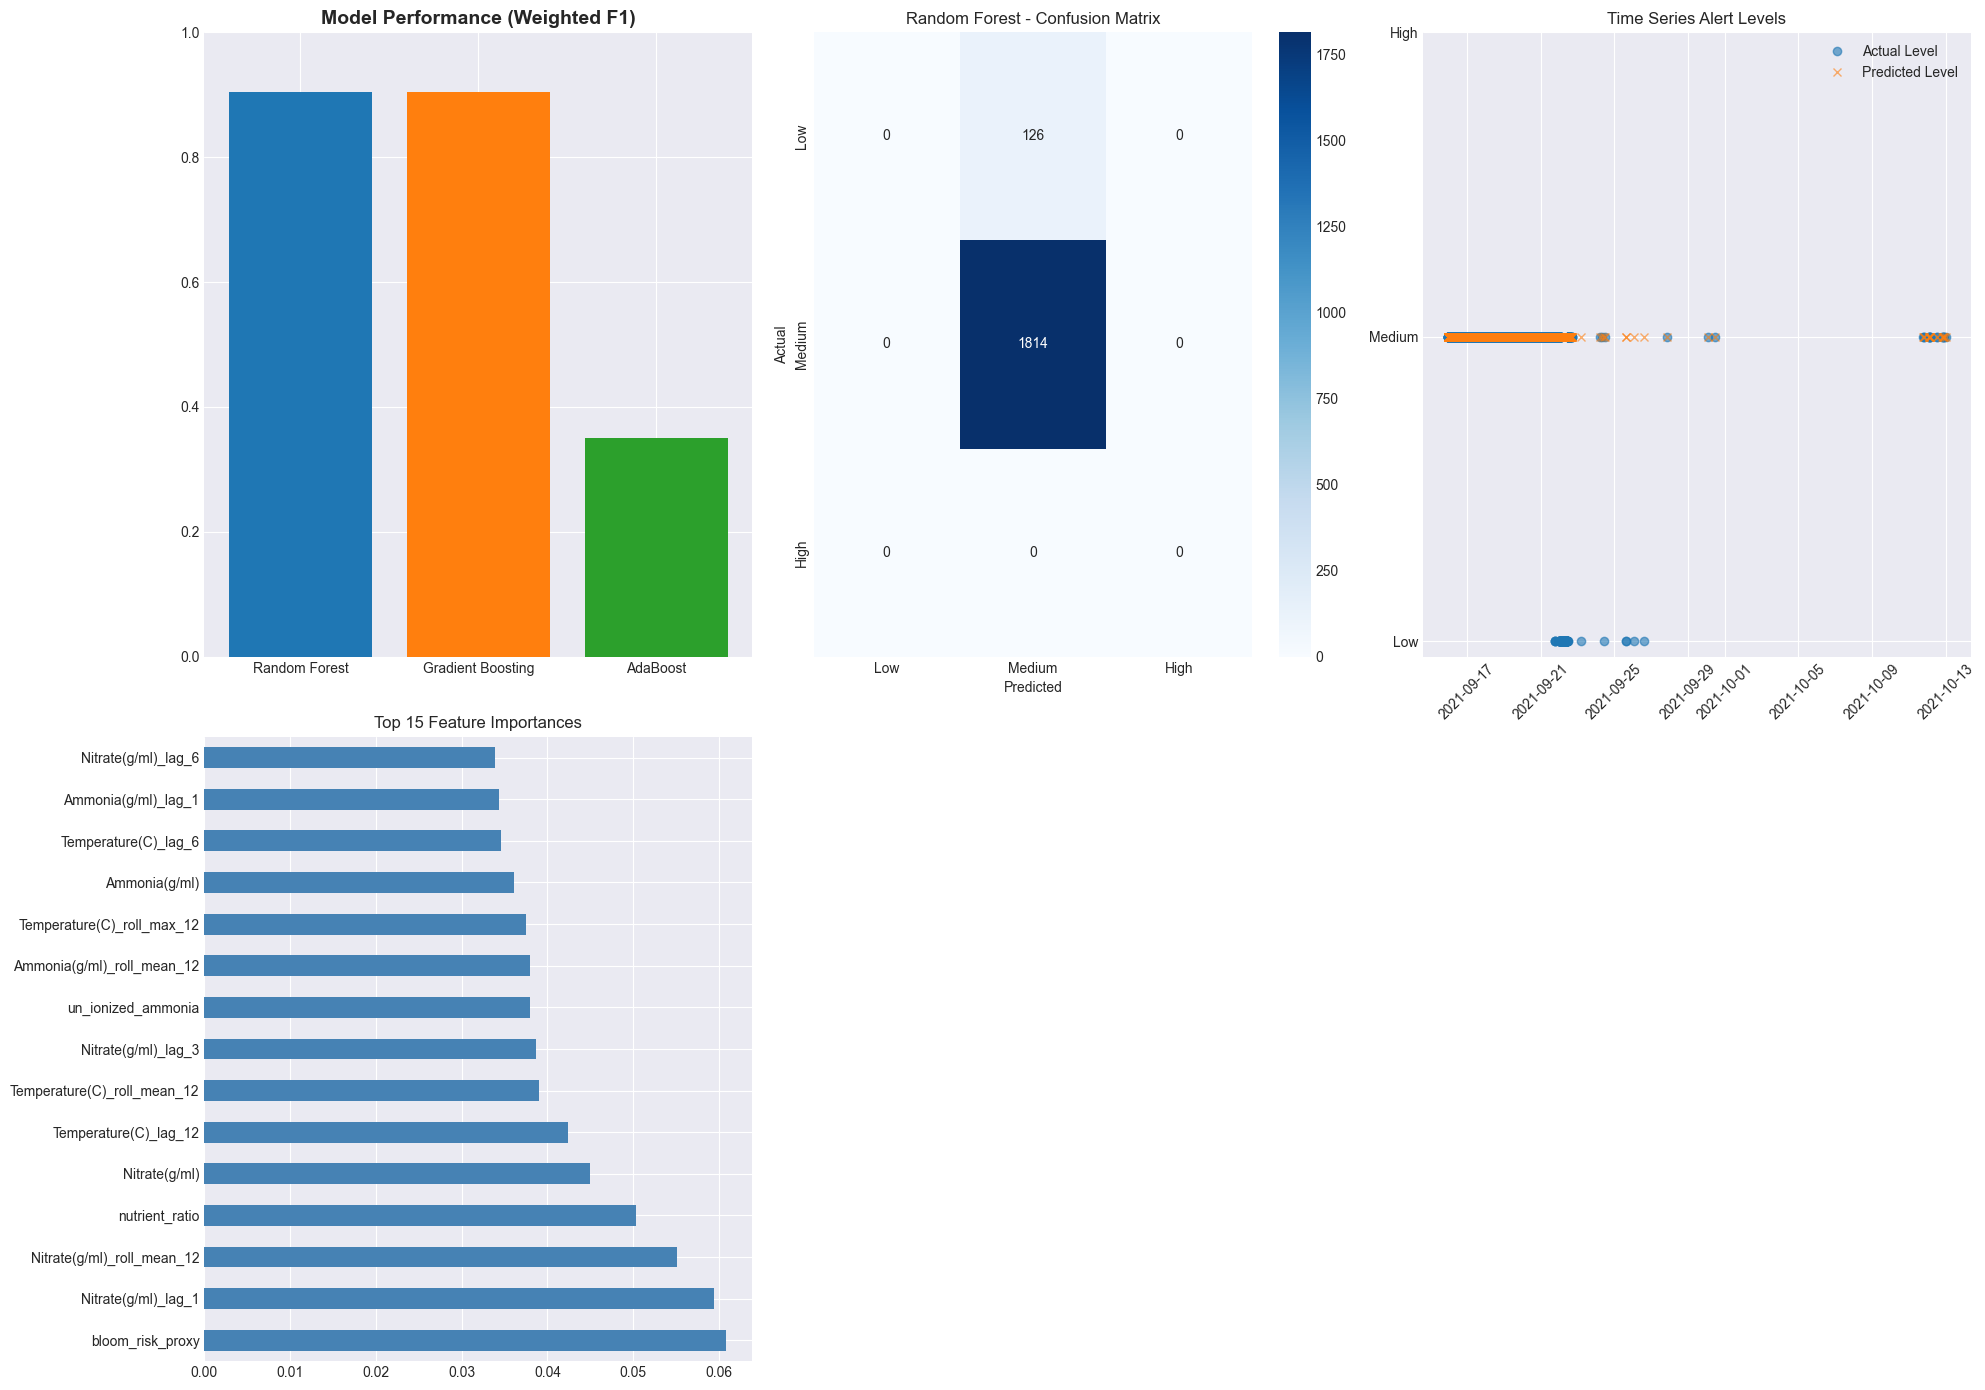

In [24]:
print("\nGenerating visualizations...")

plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(20, 14))

# 1. Model Comparison (F1)
ax1 = plt.subplot(2, 3, 1)
models_list = list(results.keys())
f1_scores = [results[m]['f1'] for m in models_list]
ax1.bar(models_list, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Model Performance (Weighted F1)', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)

# 2. Confusion Matrix Heatmap (Best Model)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=labels, yticklabels=labels)
ax2.set_title(f'{best_model} - Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. Time Series Alert Levels
ax3 = plt.subplot(2, 3, 3)
test_dates = df['created_at'].iloc[split_idx:]
# Map levels to numbers for plotting (Low=0, Medium=1, High=2)
level_map = {'Low': 0, 'Medium': 1, 'High': 2}
ax3.plot(test_dates, y_test.map(level_map), label='Actual Level', marker='o', linestyle='', alpha=0.6)
ax3.plot(test_dates, pd.Series(results[best_model]['pred']).map(level_map), label='Predicted Level', marker='x', linestyle='', alpha=0.6)
ax3.legend()
ax3.set_title('Time Series Alert Levels')
ax3.set_yticks([0, 1, 2])
ax3.set_yticklabels(labels)
plt.xticks(rotation=45)

# 4. Feature Importance (Random Forest) - unchanged
ax4 = plt.subplot(2, 3, 4)
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
importances.plot(kind='barh', ax=ax4, color='steelblue')
ax4.set_title('Top 15 Feature Importances')

plt.tight_layout()
plt.savefig('algae_classification_results.png', dpi=300, bbox_inches='tight')
print("✅ New Visualization saved: algae_classification_results.png")